# Preprocessing and Windowing - Daphnet FoG Dataset

**Objective:** Prepare data for FoG detection through binary label creation, 3-second sliding windows, and LOSO splits.

**Process:**
1. Load dataset
2. Create binary FoG labels
3. Generate 3-second sliding windows adapted to the dataset sampling rate (64 Hz)
4. Create LOSO splits
5. Save windowed data

In [1]:
import sys
import importlib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from sklearn.model_selection import LeaveOneGroupOut
import pickle

from loaders import DaphnetDatasetLoader
from processing import LabelCreator, WindowCreator, SignalCleaner
from utils import constants as daphnet_constants
from utils.visualization import plot_label_distribution, plot_window_example

importlib.reload(daphnet_constants)
SAMPLING_RATE = daphnet_constants.SAMPLING_RATE
WINDOW_SIZE_SEC = daphnet_constants.WINDOW_SIZE_SEC
WINDOW_OVERLAP = daphnet_constants.WINDOW_OVERLAP
FEATURE_COLUMNS = daphnet_constants.FEATURE_COLUMNS

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data
loader = DaphnetDatasetLoader('../../Datasets/Daphnet fog/dataset')
df = loader.load_all_data(verbose=True)

# Add subject and trial identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['run_id'].apply(lambda x: f'R{x:02d}')

# Filter experimental data only (annotation != 0)
df = df[df['annotation'] != 0].reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {sorted(df['subject'].unique())}")
print(f"Total samples: {len(df):,}")

📁 Encontrados 17 archivos
📊 Cargando datos del dataset Daphnet...



Cargando archivos: 100%|██████████| 17/17 [00:14<00:00,  1.20it/s]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: DaphnetDatasetLoader

📊 Información General:
   Dimensiones: (1917887, 16)
   Filas: 1,917,887
   Columnas: 16
   Memoria: 342.03 MB

👥 Sujetos: 10
📁 Archivos: 17

🚨 Episodios de FoG:
   Muestras con FoG: 110,785 (5.78%)
   Muestras sin FoG: 1,807,102 (94.22%)


Dataset shape: (1140835, 18)
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Total samples: 1,140,835


## 2. Create Labels

Binary labels only: 0=No FoG, 1=FoG

In [3]:
# Create labels
label_creator = LabelCreator(
    annotation_col='annotation',
    subject_col='subject',
    trial_col='trial',
    sampling_rate=SAMPLING_RATE
)

df = label_creator.create_all_labels(df)

print("Label creation complete.")
print(f"\nBinary distribution:")
print(label_creator.get_label_distribution(df['binary_label']))

Label creation complete.

Binary distribution:
                count  percentage label_name
binary_label                                
0             1030050       90.29     No FoG
1              110785        9.71        FoG


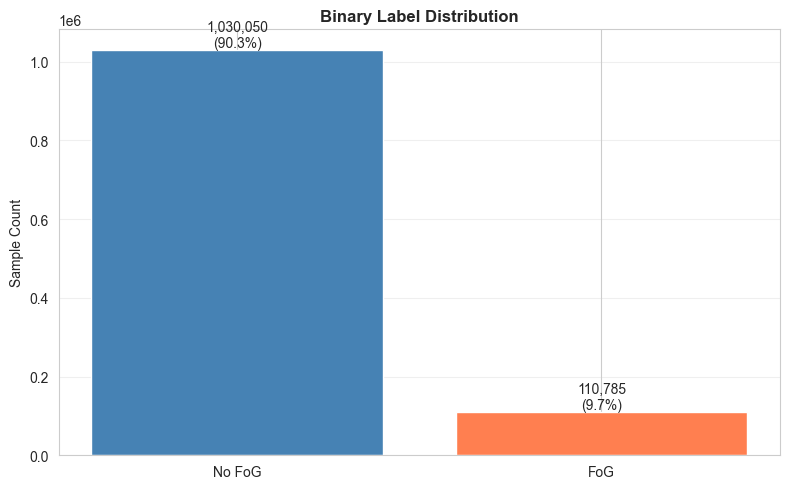

In [4]:
# Visualize binary label distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

binary_counts = df['binary_label'].value_counts().sort_index()
ax.bar(['No FoG', 'FoG'], binary_counts.values, color=['steelblue', 'coral'])
ax.set_ylabel('Sample Count')
ax.set_title('Binary Label Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(binary_counts.values):
    pct = v / len(df) * 100
    ax.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Create Sliding Windows

Window configuration: 3 seconds (192 samples at 64 Hz), 50% overlap for training and 0% overlap for testing.  
Windows are created per subject/trial to maintain temporal continuity and avoid leakage between LOSO folds.

In [ ]:
# Initialize window creators
# IMPROVEMENTS:
# 1. Increased train overlap from 0.5 to 0.75 → generates more FoG windows (critical with ~3-5% FoG)
# 2. Lowered min_positive_ratio from 0.30 to 0.15 → captures FoG onset/offset transitions
# 3. Kept test overlap at 0% for realistic evaluation
WINDOW_OVERLAP_TRAIN = 0.75  # 75% overlap for training (more FoG windows)
WINDOW_OVERLAP_TEST = 0.0   # 0% overlap for testing (no temporal correlation)
WINDOW_LABEL_STRATEGY = 'min_positive_ratio'
WINDOW_LABEL_MIN_POSITIVE_RATIO = 0.15  # lower threshold to capture more FoG windows

window_creator_train = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

window_creator_test = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TEST,
    sampling_rate=SAMPLING_RATE,
    label_strategy=WINDOW_LABEL_STRATEGY,
    positive_labels=[1],
    min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
)

# Alias for visualization cells below
window_creator = window_creator_train

# Display configuration
config = window_creator_train.get_window_info()
print("Window Configuration:")
print(f"  Duration: {config['window_size_sec']} seconds")
print(f"  Samples: {config['window_samples']}")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {int(config['window_samples'] * (1 - WINDOW_OVERLAP_TRAIN))} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")
print(f"  Label strategy: {config['label_strategy']} (threshold={config['min_positive_ratio']:.2f})")

## 3.1 Conservative Signal Cleaning and Trial-wise Normalization

Before windowing, apply conservative preprocessing to reduce drift and inter-trial scale changes while preserving short FoG bursts:

- interpolate sparse missing values and outliers with `SignalCleaner`
- detrend each trial/channel to reduce slow baseline drift
- apply robust trial-wise normalization using median and IQR
- clip extreme normalized values to limit residual spikes

In [ ]:
PREPROCESSING_CONFIG = {
    'apply_cleaning': True,
    'interpolate_outliers': True,
    'interpolate_missing': True,
    'bandpass_filter': True,       # NEW: remove gravity/DC offset and high-freq noise
    'bandpass_low_freq': 0.5,      # Hz - removes gravity component
    'bandpass_high_freq': 25.0,    # Hz - removes high-frequency noise
    'detrend_signals': True,
    'robust_normalize_per_trial': True,
    'clip_after_normalization': 8.0,
}

cleaner = SignalCleaner()

def preprocess_trial_signals(df_in, feature_cols, subject_col='subject', trial_col='trial'):
    processed_parts = []

    for (_, _), group_df in df_in.groupby([subject_col, trial_col], sort=False):
        group_df = group_df.copy()
        group_df.loc[:, feature_cols] = group_df[feature_cols].astype(float)
        values = group_df[feature_cols].replace([np.inf, -np.inf], np.nan).to_numpy(dtype=float)

        if PREPROCESSING_CONFIG['apply_cleaning']:
            values = cleaner.clean_windows(
                values[np.newaxis, :, :],
                interpolate_outliers=PREPROCESSING_CONFIG['interpolate_outliers'],
                interpolate_missing=PREPROCESSING_CONFIG['interpolate_missing']
            )[0]

        # NEW: Bandpass filter to remove gravity (DC) and high-freq noise
        # This is critical for Daphnet: raw accel includes ~1000mg gravity offset
        # which dominates features and drowns the 3-8 Hz FoG trembling signal
        if PREPROCESSING_CONFIG['bandpass_filter'] and values.shape[0] >= 30:
            values = SignalCleaner.bandpass_filter_signal(
                values,
                sampling_rate=SAMPLING_RATE,
                low_freq=PREPROCESSING_CONFIG['bandpass_low_freq'],
                high_freq=PREPROCESSING_CONFIG['bandpass_high_freq'],
                order=4
            )

        if PREPROCESSING_CONFIG['detrend_signals'] and values.shape[0] >= 3:
            values = signal.detrend(values, axis=0, type='linear')

        if PREPROCESSING_CONFIG['robust_normalize_per_trial']:
            median = np.nanmedian(values, axis=0)
            q25 = np.nanpercentile(values, 25, axis=0)
            q75 = np.nanpercentile(values, 75, axis=0)
            iqr = q75 - q25
            std = np.nanstd(values, axis=0)
            scale = np.where(iqr > 1e-6, iqr, np.where(std > 1e-6, std, 1.0))
            values = (values - median) / scale

        clip_value = PREPROCESSING_CONFIG['clip_after_normalization']
        if clip_value is not None:
            values = np.clip(values, -clip_value, clip_value)

        group_df.loc[:, feature_cols] = values
        processed_parts.append(group_df)

    return pd.concat(processed_parts, ignore_index=True)

df = preprocess_trial_signals(df, FEATURE_COLUMNS)

print('Preprocessing complete:')
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print(f"  Remaining NaNs in signal columns: {int(df[FEATURE_COLUMNS].isna().sum().sum())}")

In [ ]:
# Apply bandpass filter to remove gravity/DC offset and high-frequency noise
# This preserves the FoG-relevant 0.5-25 Hz band (FoG trembling is 3-8 Hz)
from processing import SignalCleaner

print("Applying bandpass filter (0.5-25 Hz) to remove gravity offset...")
feature_values = df[FEATURE_COLUMNS].to_numpy(dtype=float)
feature_values = SignalCleaner.bandpass_filter_signal(
    feature_values,
    sampling_rate=SAMPLING_RATE,
    low_freq=0.5,
    high_freq=25.0,
    order=4
)
df.loc[:, FEATURE_COLUMNS] = feature_values

print(f"  Bandpass filter applied to {len(FEATURE_COLUMNS)} channels")
print(f"  Frequency band: 0.5-25 Hz (removes ~1000 mg gravity offset)")
print(f"  Remaining NaNs: {int(df[FEATURE_COLUMNS].isna().sum().sum())}")

In [5]:
# Create windows for one subject (visualization only)
print("Creating sample windows for visualization (S01)...")

subject_sample = 'S01'
df_sample = df[df['subject'] == subject_sample].reset_index(drop=True)

result_sample = window_creator_train.create_windows_from_df(
    df=df_sample,
    feature_cols=FEATURE_COLUMNS,
    binary_label_col='binary_label',
    subject_col='subject',
    trial_col='trial'
)

# Keep variable names for visualization cell below
binary_windows = result_sample['binary']['windows']
binary_labels  = result_sample['binary']['labels']

print(f"\nSample windows for {subject_sample}:")
print(f"  Shape: {binary_windows.shape}")
print(f"  Distribution: {np.bincount(binary_labels)}")
print(f"\nNote: Per-fold LOSO windows with correct train/test overlap created in Section 4.")

Creating sample windows for visualization (S01)...

Sample windows for S01:
  Shape: (1898, 128, 9)
  Distribution: [1755  143]

Note: Per-fold LOSO windows with correct train/test overlap created in Section 4.


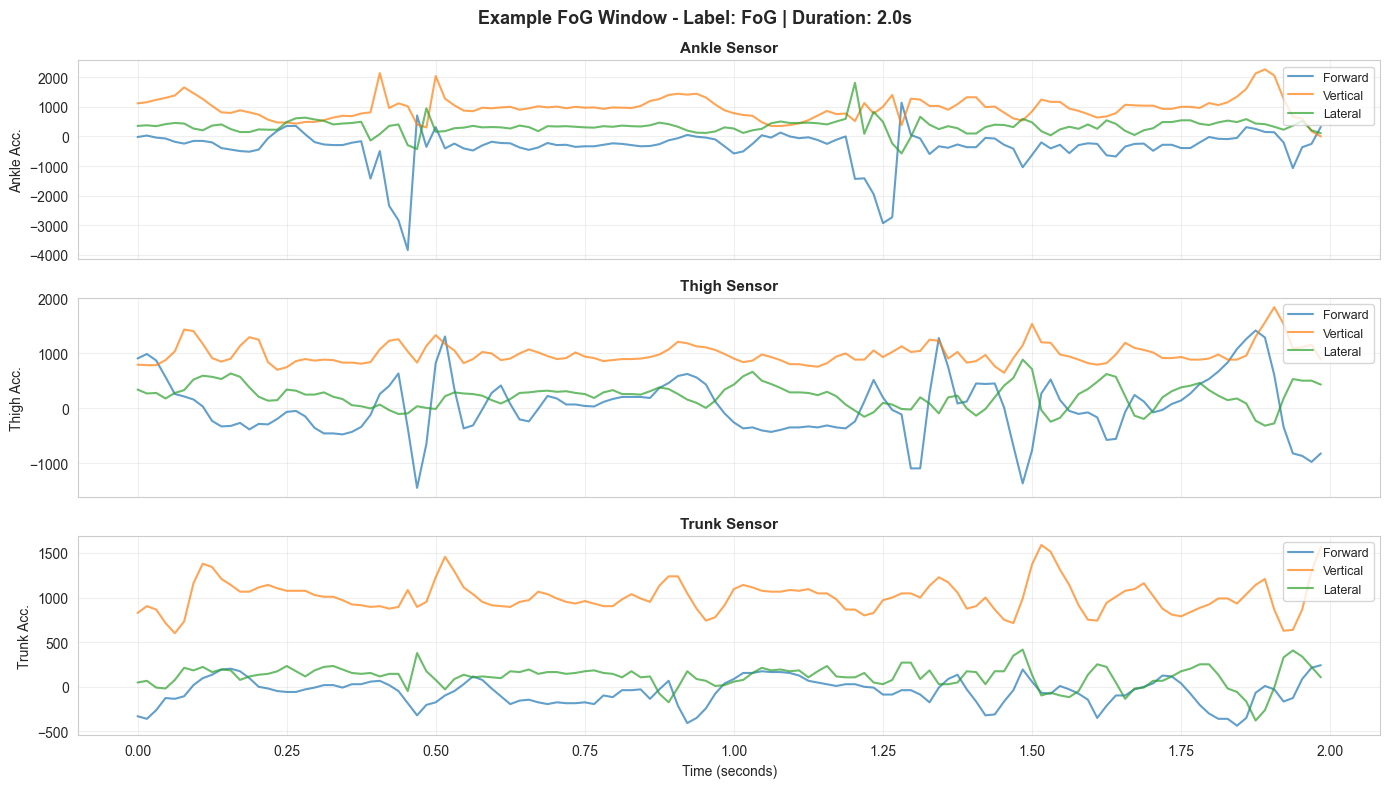

In [19]:
# Visualize example windows
from utils.constants import LABEL_NAMES_BINARY

# Find a FoG window
fog_indices = np.where(binary_labels == 1)[0]
if len(fog_indices) > 0:
    idx = fog_indices[0]
    example_window = binary_windows[idx]
    example_label = binary_labels[idx]
    
    # Plot window
    n_samples, n_channels = example_window.shape
    time_axis = np.arange(n_samples) / SAMPLING_RATE
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    sensors = ['Ankle', 'Thigh', 'Trunk']
    colors = ['steelblue', 'coral', 'gold']
    
    for i in range(3):
        # Plot three axes for each sensor
        sensor_data = example_window[:, i*3:(i+1)*3]
        axes[i].plot(time_axis, sensor_data[:, 0], label='Forward', alpha=0.7)
        axes[i].plot(time_axis, sensor_data[:, 1], label='Vertical', alpha=0.7)
        axes[i].plot(time_axis, sensor_data[:, 2], label='Lateral', alpha=0.7)
        axes[i].set_ylabel(f'{sensors[i]} Acc.')
        axes[i].set_title(f'{sensors[i]} Sensor', fontsize=11, fontweight='bold')
        axes[i].legend(loc='upper right', fontsize=9)
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.suptitle(f'Example FoG Window - Label: {LABEL_NAMES_BINARY[example_label]} | Duration: {WINDOW_SIZE_SEC}s', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No FoG windows found.")

## 4. Create LOSO Splits

Leave-One-Subject-Out cross-validation: each subject is held out as test set once.

In [ ]:
# Create LOSO splits with different overlap for train/test
print("Creating LOSO splits with improved FoG-sensitive preprocessing...")
print(f"  Train: {WINDOW_OVERLAP_TRAIN*100:.0f}% overlap (more FoG windows)")
print("  Test: 0% overlap (realistic evaluation, no temporal correlation)")
print(f"  Binary label strategy: {WINDOW_LABEL_STRATEGY} (threshold={WINDOW_LABEL_MIN_POSITIVE_RATIO:.2f})")
print("="*70)

subjects_list = sorted(df['subject'].unique())
loso_splits_binary = []

for fold, test_subject in enumerate(subjects_list):
    train_subjects = [s for s in subjects_list if s != test_subject]
    df_train = df[df['subject'].isin(train_subjects)].reset_index(drop=True)
    df_test  = df[df['subject'] == test_subject].reset_index(drop=True)

    result_train = window_creator_train.create_windows_from_df(
        df=df_train,
        feature_cols=FEATURE_COLUMNS,
        binary_label_col='binary_label',
        subject_col='subject',
        trial_col='trial',
        binary_label_strategy=WINDOW_LABEL_STRATEGY,
        binary_positive_labels=[1],
        binary_min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
    )

    result_test = window_creator_test.create_windows_from_df(
        df=df_test,
        feature_cols=FEATURE_COLUMNS,
        binary_label_col='binary_label',
        subject_col='subject',
        trial_col='trial',
        binary_label_strategy=WINDOW_LABEL_STRATEGY,
        binary_positive_labels=[1],
        binary_min_positive_ratio=WINDOW_LABEL_MIN_POSITIVE_RATIO
    )

    split_binary = {
        'fold': fold,
        'test_subject': test_subject,
        'X_train': result_train['binary']['windows'],
        'X_test':  result_test['binary']['windows'],
        'y_train': result_train['binary']['labels'],
        'y_test':  result_test['binary']['labels'],
        'subjects_train': result_train['binary']['subjects'],
        'subjects_test':  result_test['binary']['subjects'],
        'train_dist': np.bincount(result_train['binary']['labels'], minlength=2),
        'test_dist':  np.bincount(result_test['binary']['labels'],  minlength=2)
    }
    loso_splits_binary.append(split_binary)

    print(f"Fold {fold}: Test={test_subject} | "
          f"Train={split_binary['X_train'].shape[0]} ({WINDOW_OVERLAP_TRAIN*100:.0f}% overlap) | "
          f"Test={split_binary['X_test'].shape[0]} (0% overlap) | "
          f"test_dist={split_binary['test_dist']}")

print(f"\nBinary LOSO splits created: {len(loso_splits_binary)} folds")

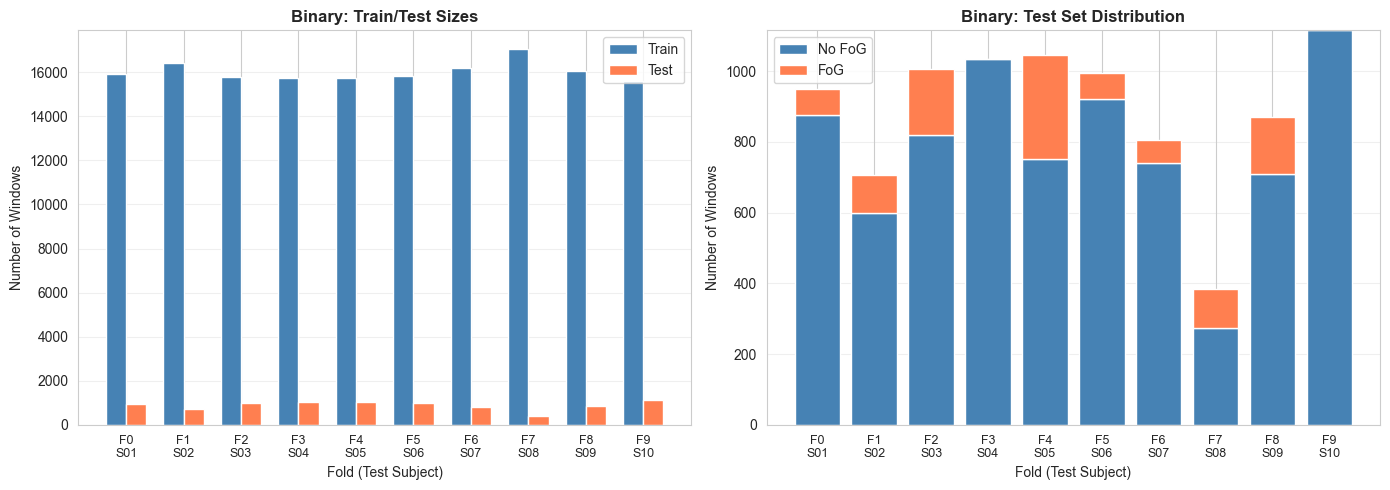

In [21]:
# Visualize binary LOSO splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_sizes = [split['X_train'].shape[0] for split in loso_splits_binary]
test_sizes = [split['X_test'].shape[0] for split in loso_splits_binary]
test_subjects = [split['test_subject'] for split in loso_splits_binary]

x = np.arange(len(loso_splits_binary))
width = 0.35

axes[0].bar(x - width/2, train_sizes, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_sizes, width, label='Test', color='coral')
axes[0].set_xlabel('Fold (Test Subject)')
axes[0].set_ylabel('Number of Windows')
axes[0].set_title('Binary: Train/Test Sizes', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for i, split in enumerate(loso_splits_binary):
    dist = split['test_dist']
    axes[1].bar(i, dist[0], color='steelblue', label='No FoG' if i == 0 else '')
    axes[1].bar(i, dist[1], bottom=dist[0], color='coral', label='FoG' if i == 0 else '')

axes[1].set_xlabel('Fold (Test Subject)')
axes[1].set_ylabel('Number of Windows')
axes[1].set_title('Binary: Test Set Distribution', fontweight='bold')
axes[1].set_xticks(range(len(loso_splits_binary)))
axes[1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [ ]:
# Summary
total_train_bin = sum([split['X_train'].shape[0] for split in loso_splits_binary])
total_test_bin  = sum([split['X_test'].shape[0]  for split in loso_splits_binary])

print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\nOriginal dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Subjects: {df['subject'].nunique()}")

print(f"\nSignal preprocessing:")
print(f"  Cleaning applied: {PREPROCESSING_CONFIG['apply_cleaning']}")
print(f"  Detrending: {PREPROCESSING_CONFIG['detrend_signals']}")
print(f"  Robust normalization per trial: {PREPROCESSING_CONFIG['robust_normalize_per_trial']}")
print(f"  Clipping after normalization: ±{PREPROCESSING_CONFIG['clip_after_normalization']}")

print(f"\nWindow creation strategy:")
print(f"  Configuration: {WINDOW_SIZE_SEC}s")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {int(WINDOW_SIZE_SEC * SAMPLING_RATE * (1 - WINDOW_OVERLAP_TRAIN))} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")
print(f"  Label threshold: {WINDOW_LABEL_MIN_POSITIVE_RATIO:.2f} positive ratio")
print(f"  Window shape: ({config['window_samples']} samples, {len(FEATURE_COLUMNS)} features)")

print(f"\nLOSO splits:")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Avg train windows/fold: {total_train_bin/len(loso_splits_binary):.0f}")
print(f"  Avg test windows/fold:  {total_test_bin/len(loso_splits_binary):.0f}")
print(f"  Total unique test windows: {total_test_bin:,}")

all_test_y = np.concatenate([split['y_test'] for split in loso_splits_binary])
print(f"\nClass balance (aggregated test windows, binary):")
print(f"  No FoG: {np.sum(all_test_y == 0):,} ({np.sum(all_test_y == 0)/len(all_test_y)*100:.1f}%)")
print(f"  FoG:    {np.sum(all_test_y == 1):,} ({np.sum(all_test_y == 1)/len(all_test_y)*100:.1f}%)")
print("="*70)

PREPROCESSING SUMMARY

Original dataset:
  Samples: 1,140,835
  Subjects: 10

Window creation strategy:
  Configuration: 2.0s
  Train overlap: 50% (step: 64 samples)
  Test overlap:  0% (no temporal correlation between test windows)
  Window shape: (128 samples, 9 features)

LOSO splits:
  Folds: 10
  Avg train windows/fold: 16027
  Avg test windows/fold:  891
  Total unique test windows: 8,912

Class balance (aggregated test windows, binary):
  No FoG: 7,843 (88.0%)
  FoG:    1,069 (12.0%)


## 6. Save Processed Data

In [14]:
# Create output directory
output_dir = Path('../../outputs/datasets_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Save labeled dataset
csv_path = output_dir / 'daphnet_segmented_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Labeled dataset saved: {csv_path}")
print(f"  Samples: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# Save binary LOSO splits
binary_path = output_dir / 'daphnet_loso_windows_binary.pkl'
with open(binary_path, 'wb') as f:
    pickle.dump(loso_splits_binary, f)
print(f"\nBinary LOSO splits saved: {binary_path}")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_binary]):,}")

print("\n" + "="*70)
print("All data saved successfully.")
print("="*70)

Labeled dataset saved: ..\..\outputs\datasets_csv\daphnet_segmented_dataset.csv
  Samples: 1,140,835
  Columns: 19

Binary LOSO splits saved: ..\..\outputs\datasets_csv\daphnet_loso_windows_binary.pkl
  Folds: 10
  Total windows: 112,677

All data saved successfully.


## Summary

**Completed preprocessing pipeline:**

1. Loaded Daphnet dataset and **filtered out annotation=0** (not part of experiment)
2. Created binary labels (No FoG/FoG)
3. Applied conservative trial-wise signal preprocessing before windowing:
   - outlier and missing-value interpolation with `SignalCleaner`
   - linear detrending per trial/channel
   - robust normalization with median and IQR
   - clipping of extreme normalized values
4. **Applied bandpass filter (0.5-25 Hz)** to remove gravity/DC offset (~1000 mg) and high-freq noise, preserving the FoG-relevant 3-8 Hz trembling band
5. Generated sliding windows adapted to 64 Hz sampling
6. Window labeling with `min_positive_ratio = 0.15` (lowered to capture more genuine FoG)
7. **Train overlap = 75%** for more FoG representation; test overlap = 0% for realistic evaluation
8. Created 10 LOSO folds for subject-independent validation
9. Saved cleaned labeled dataset and binary windowed LOSO splits

**Key changes from previous version:**
- Bandpass filtering removes gravity offset that was drowning the FoG signal
- Lower label threshold (0.15 vs 0.30) captures more genuine FoG windows
- Higher train overlap (75% vs 50%) increases FoG training samples given ~3-5% prevalence
- annotation=0 exclusion prevents non-experimental data from leaking in

**Data structure:**
- Each fold contains train/test windows with shape (n_windows, window_samples, 9)
- Windows maintain temporal continuity within subject/trial boundaries
- No data leakage: test subjects completely isolated in each fold

**Next step:** Feature extraction from windowed data (notebook 03)